In [1]:
import sys
sys.path.insert(0, r"D:\OCRbyGPU\PIL_fix")
import os
import cv2  
import ultralytics
from ultralytics import YOLO
model = YOLO(r'c:\Users\HP\Desktop\ID_OCR\detect_id_card.pt')
import matplotlib.pyplot as plt
import numpy as np

Shape: (274, 387, 3)


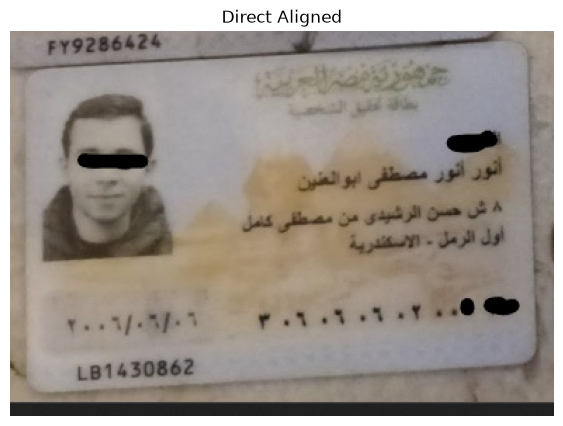

In [2]:
direct_aligned = cv2.imread(
    r"c:\Users\HP\Desktop\ids2026\InkedScreenshot 2026-08-16 144825_LI.jpg"
)
print("Shape:", direct_aligned.shape)
plt.figure(figsize=(8, 5))
plt.imshow(
    cv2.cvtColor(
        direct_aligned,
        cv2.COLOR_BGR2RGB
    )
)
plt.title("Direct Aligned")
plt.axis("off")
plt.show()

Gray shape: (274, 387)


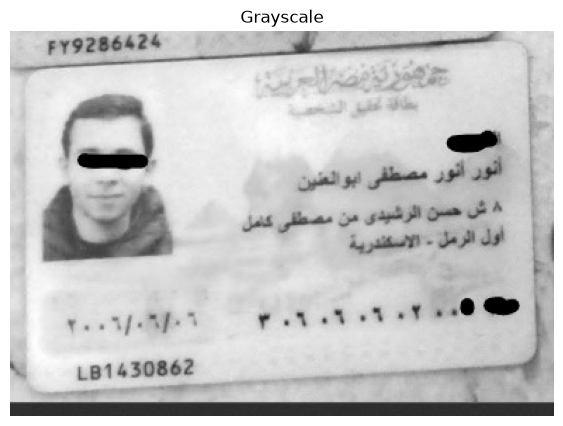

In [3]:
gray = cv2.cvtColor(
    direct_aligned,
    cv2.COLOR_BGR2GRAY
)

print("Gray shape:", gray.shape)

plt.figure(figsize=(8, 5))

plt.imshow(
    gray,
    cmap="gray"
)

plt.title("Grayscale")

plt.axis("off")

plt.show()

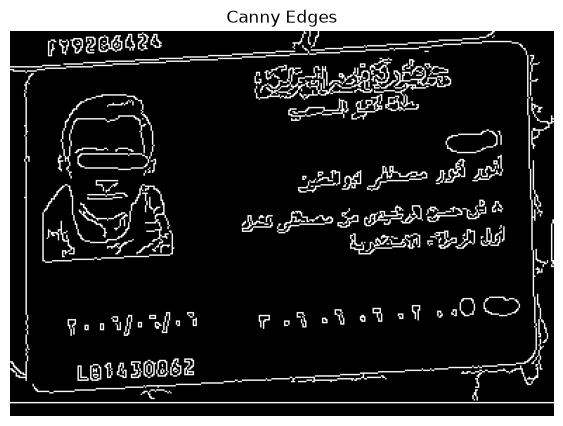

In [4]:
edges = cv2.Canny(
    gray,
    25,
    100
)
plt.figure(figsize=(8, 5))

plt.imshow(
    edges,
    cmap="gray"
)

plt.title("Canny Edges")
plt.axis("off")

plt.show()

In [5]:
lines = cv2.HoughLinesP(
    edges,
    1,
    np.pi / 180,
    threshold=80,
    minLineLength=200,
    maxLineGap=30
)
len(lines)

8

In [6]:
lines[1]

array([[  0,  27, 299,  11]], dtype=int32)

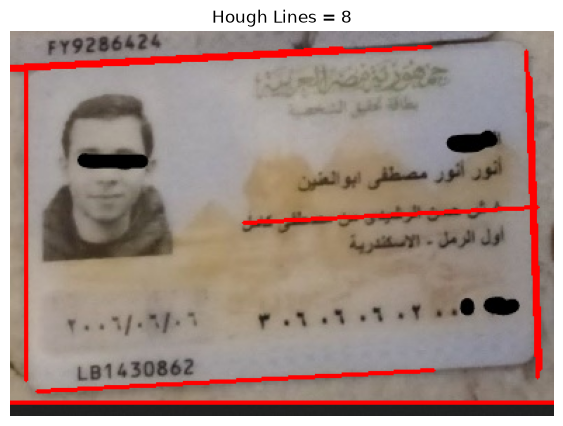

In [7]:
line_image = direct_aligned.copy()

for line in lines:

    x1, y1, x2, y2 = line[0]

    cv2.line(
        line_image,
        (x1, y1),
        (x2, y2),
        (0, 0, 255),
        2
    )

plt.figure(figsize=(10, 5))

plt.imshow(
    cv2.cvtColor(
        line_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    f"Hough Lines = {len(lines)}"
)

plt.axis("off")

plt.show()

# اول خط 

In [8]:
x1, y1, x2, y2 = lines[0][0]
x1

np.int32(0)

# طوله 

In [9]:
length = np.sqrt(
    (x2 - x1)**2 +
    (y2 - y1)**2
)

print("x1:", x1)
print("y1:", y1)
print("x2:", x2)
print("y2:", y2)
print("Length:", length)

x1: 0
y1: 264
x2: 386
y2: 264
Length: 386.0


# زاويته

In [10]:
angle = np.arctan2(
        y2 - y1,
        x2 - x1
    )

print("Angle:", angle)

Angle: 0.0


In [11]:
for i, line in enumerate(lines):

    x1, y1, x2, y2 = line[0]

    length = np.sqrt(
        (x2 - x1)**2 +
        (y2 - y1)**2
    )

    angle = np.degrees(
        np.arctan2(
            y2 - y1,
            x2 - x1
        )
    )

    print(
        f"Line {i}: "
        f"Length = {length:.2f}, "
        f"Angle = {angle:.2f}°"
    )

Line 0: Length = 386.00, Angle = 0.00°
Line 1: Length = 299.43, Angle = -3.06°
Line 2: Length = 236.36, Angle = -3.15°
Line 3: Length = 282.40, Angle = -3.04°
Line 4: Length = 223.00, Angle = -90.00°
Line 5: Length = 232.14, Angle = 88.03°
Line 6: Length = 209.29, Angle = -3.01°
Line 7: Length = 207.12, Angle = 88.06°


In [12]:
angles = []

for line in lines:

    x1, y1, x2, y2 = line[0]

    length = np.sqrt(
        (x2 - x1)**2 +
        (y2 - y1)**2
    )

    angle = np.degrees(
        np.arctan2(
            y2 - y1,
            x2 - x1
        )
    )

    if length > 200 and abs(angle) < 10:

        angles.append(angle)

print("Accepted angles:", angles)
print("Number of accepted lines:", len(angles))

Accepted angles: [np.float64(0.0), np.float64(-3.0630734132599247), np.float64(-3.152937007775314), np.float64(-3.0447784441939847), np.float64(-3.0127875041833403)]
Number of accepted lines: 5


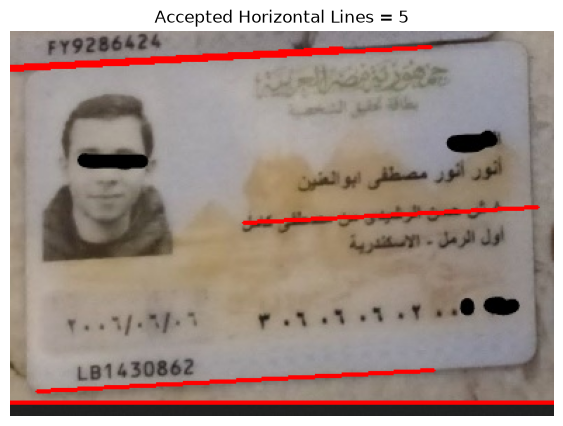

In [13]:
filtered_image = direct_aligned.copy()

accepted_lines = 0

for line in lines:

    x1, y1, x2, y2 = line[0]

    length = np.sqrt(
        (x2 - x1)**2 +
        (y2 - y1)**2
    )

    angle = np.degrees(
        np.arctan2(
            y2 - y1,
            x2 - x1
        )
    )

    if length > 200 and abs(angle) < 10:

        cv2.line(
            filtered_image,
            (x1, y1),
            (x2, y2),
            (0, 0, 255),
            2
        )

        accepted_lines += 1

plt.figure(figsize=(10, 5))

plt.imshow(
    cv2.cvtColor(
        filtered_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    f"Accepted Horizontal Lines = {accepted_lines}"
)

plt.axis("off")

plt.show()

In [14]:
angle = np.median(angles)

print("Angles:", angles)
print("Median angle:", angle)

Angles: [np.float64(0.0), np.float64(-3.0630734132599247), np.float64(-3.152937007775314), np.float64(-3.0447784441939847), np.float64(-3.0127875041833403)]
Median angle: -3.0447784441939847


In [15]:
h, w = direct_aligned.shape[:2]

print("Height:", h)
print("Width:", w)

Height: 274
Width: 387


In [16]:
center = (
    w // 2,
    h // 2
)

print("Center:", center)

Center: (193, 137)


In [17]:
M = cv2.getRotationMatrix2D(
    center,
    angle,
    1.0
)

print(M)

[[    0.99859   -0.053116      7.5494]
 [   0.053116     0.99859     -10.058]]


In [18]:
rotated2 = cv2.warpAffine(
    direct_aligned,
    M,
    (w, h),
    flags=cv2.INTER_CUBIC,
    borderMode=cv2.BORDER_REPLICATE
)

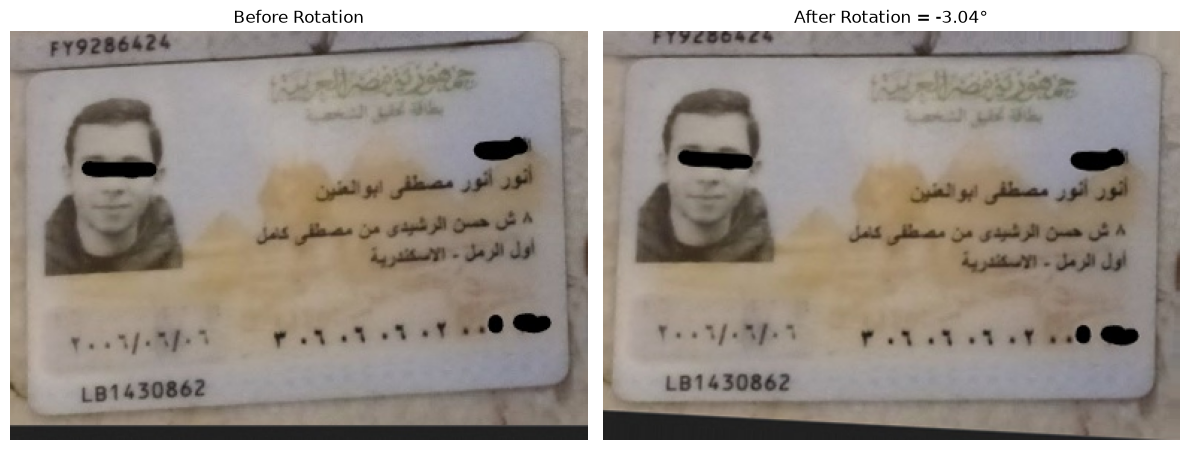

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.imshow(
    cv2.cvtColor(
        direct_aligned,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Before Rotation")

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    cv2.cvtColor(
        rotated2,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    f"After Rotation = {angle:.2f}°"
)

plt.axis("off")

plt.tight_layout()

plt.show()

In [20]:
model = YOLO(r'c:\Users\HP\Desktop\ID_OCR\detect_id_card.pt')
results = model(rotated2)
result =results[0]
x1, y1, x2, y2 = result.boxes.xyxy[0].int().tolist()


0: 480x640 1 front-up, 43.4ms
Speed: 48.8ms preprocess, 43.4ms inference, 17.6ms postprocess per image at shape (1, 3, 480, 640)


In [21]:
image = rotated2.copy()

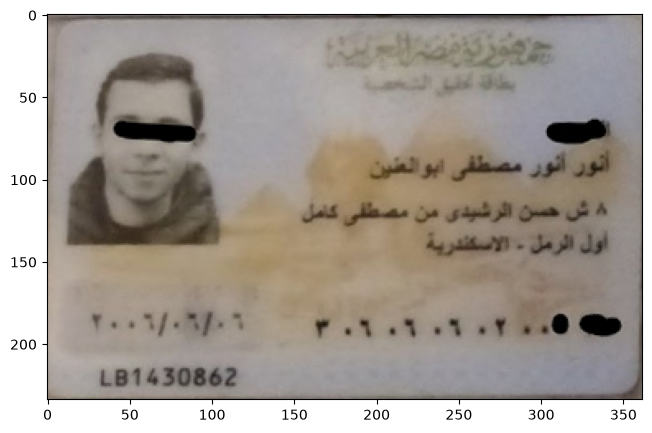

In [22]:
card = image[y1:y2, x1:x2]
plt.figure(figsize=(8, 5))
plt.imshow(
    cv2.cvtColor(
        card,
        cv2.COLOR_BGR2RGB
    )
)